In [24]:
# Imports and configs
%load_ext autoreload
%autoreload 2

import pandas as pd
import src.helpers.data_pipeline_helpers as dph
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 120)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
# Load the crime dataset
crime_df = dph.load_crime_data()

In [26]:
# We want to generate rows for every day-hour combination in 2022-2023
calendar_df = dph.generate_calendar_df()

In [27]:
# Add the game day / time information to the data set
combined_schedule = dph.build_combined_schedule()

In [28]:
# We want to find census blocks in radius to add to our data set
blocks_m = dph.build_census_blocks()

Blocks CRS before: EPSG:4269
Stadium contained in a block (original CRS)? True
Min distance (m): 0.0
               block_id      dist_m
446653  060379800101022    0.000000
363534  060371977003009  467.388189
342360  060372060101007  468.237558
394297  060371977003008  469.915411
220136  060379800101021  480.110769
Treated blocks: 30
Control ring blocks: 241


In [29]:
# Join calendar and block data
calendar_with_block_df = calendar_df.merge(
    blocks_m,
    how="cross"
)

In [30]:
# Map each crime location to a block id
crime_df = dph.map_crimes_to_blocks(crime_df, blocks_m)

In [31]:
# Transform dataset so we have count of crimes per day per hour
crime_summary_df = dph.build_crime_summary(crime_df)

In [32]:
# Join calendar and crime data frames and populate empty crime counts as 0
summary_df = calendar_with_block_df.merge(
    crime_summary_df,
    how="left",
    left_on=["date", "hour", "block_id"],
    right_on=["DATE OCC", "hour", "block_id"]
)

summary_df["crime_count"] = summary_df["crime_count"].fillna(0)
summary_df = summary_df[["date", "hour", "dow_hour", "block_id", "adjacent", "geometry", "post_rule_change", "crime_count"]]

In [33]:
# Join summary df with game hour df
summary_df = summary_df.merge(
    combined_schedule,
    how="left",
    on=["date", "hour"]
)

In [34]:
# For hours where there is no game, is_game_hour will be false and attendance will be 0
summary_df["is_game_hour"] = summary_df["is_game_hour"].fillna(0)
summary_df["is_night_game"] = summary_df["is_night_game"].fillna(0)
summary_df["attendance"] = summary_df["attendance"].fillna(0)

In [35]:
# Add the weather information to the data set
combined_weather = dph.build_weather_df()

/Users/c1burns/Documents/UTD/BUAN 6312/Project/src/helpers/data_pipeline_helpers.py:189: DtypeWarning: Columns (19,22,23,24,25,26,27,28,29,30,31,32,33,37,44,60,61,63,64,67,69,73,77,78,79) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_2022_df = pd.read_csv(weather_2022_path, header=0)
/Users/c1burns/Documents/UTD/BUAN 6312/Project/src/helpers/data_pipeline_helpers.py:191: DtypeWarning: Columns (37,44,73) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_2023_df = pd.read_csv(weather_2023_path, header=0)


In [36]:
# Join weather with summary data frame
summary_df = summary_df.merge(
    combined_weather,
    how="left",
    on=["date", "hour"]
)

# There are a few hours where we don't have a weather forecast, so just use the previous hour
summary_df = summary_df.sort_values(["date", "hour"])
weather_cols = ["Wind", "Visibility", "Temperature", "Precipitation"]
summary_df[weather_cols] = summary_df[weather_cols].ffill()

summary_df.head()
summary_df.columns

Index(['date', 'hour', 'dow_hour', 'block_id', 'adjacent', 'geometry', 'post_rule_change', 'crime_count', 'attendance',
       'is_game_hour', 'is_night_game', 'Wind', 'Visibility', 'Temperature', 'Precipitation'],
      dtype='object')

In [37]:
# Combine date + hour into one time index
summary_df["datetime"] = pd.to_datetime(summary_df["date"]) + pd.to_timedelta(summary_df["hour"], unit="h")

# Prepared data frame for fit
vars_used = [
    "crime_count", "adjacent", "post_rule_change", "is_game_hour", "block_id", "date", "dow_hour", "attendance", "Wind", "Visibility", "Temperature", "Precipitation", "datetime", "is_night_game"
]

summary_df = summary_df[vars_used]

# Save file to parquet
project_dir = Path().resolve()
output_path = project_dir / ".." / "data" / "processed" / "model_dataset.parquet"
summary_df.to_parquet(output_path)

# Set panel index: entity = block_id, time = datetime
summary_df = summary_df.set_index(["block_id", "datetime"]).sort_index()

/var/folders/np/_kvrcgpn26v8_m1zffvl92lc0000gn/T/ipykernel_92033/126837354.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_change_df['week'] = pre_change_df['date'].dt.to_period('W').apply(lambda r: r.start_time)


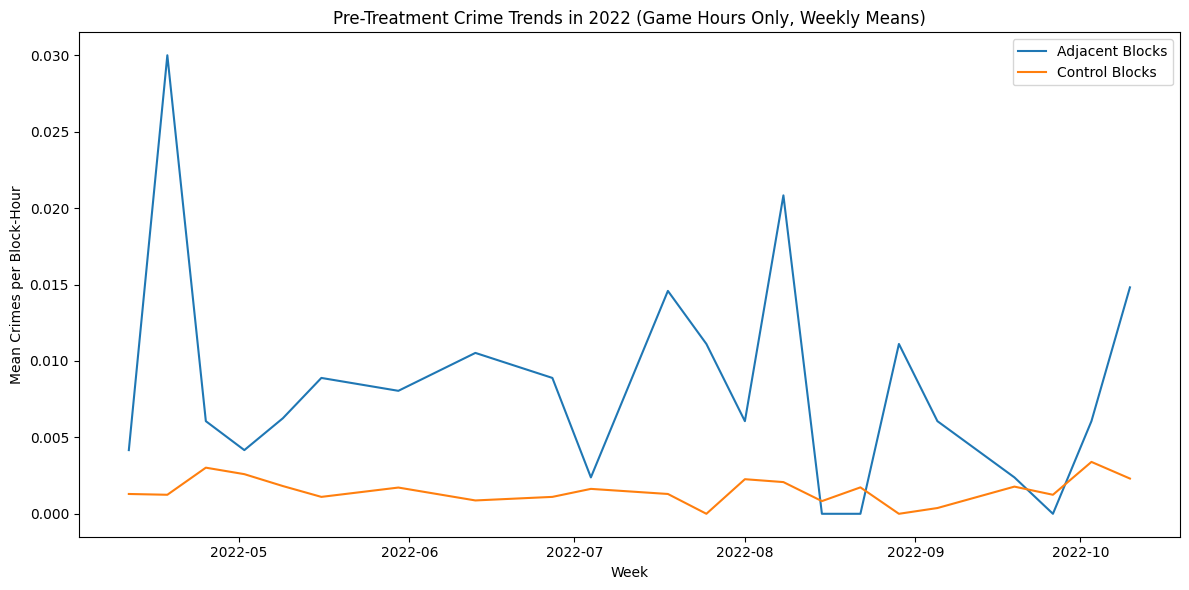

In [38]:
# Visualizations for report
pre_change_df = summary_df[summary_df["post_rule_change"] == False]
pre_change_df['week'] = pre_change_df['date'].dt.to_period('W').apply(lambda r: r.start_time)
game_df = pre_change_df[pre_change_df['is_game_hour'] == 1]

weekly_game = (
    game_df.groupby(['week', 'adjacent'])['crime_count']
           .mean()
           .reset_index()
)

plt.figure(figsize=(12, 6))

for adj_val, label in [(1, "Adjacent Blocks"), (0, "Control Blocks")]:
    temp = weekly_game[weekly_game['adjacent'] == adj_val]
    plt.plot(temp['week'], temp['crime_count'], label=label)

plt.title("Pre-Treatment Crime Trends in 2022 (Game Hours Only, Weekly Means)")
plt.xlabel("Week")
plt.ylabel("Mean Crimes per Block-Hour")
plt.legend()
plt.tight_layout()
plt.show()

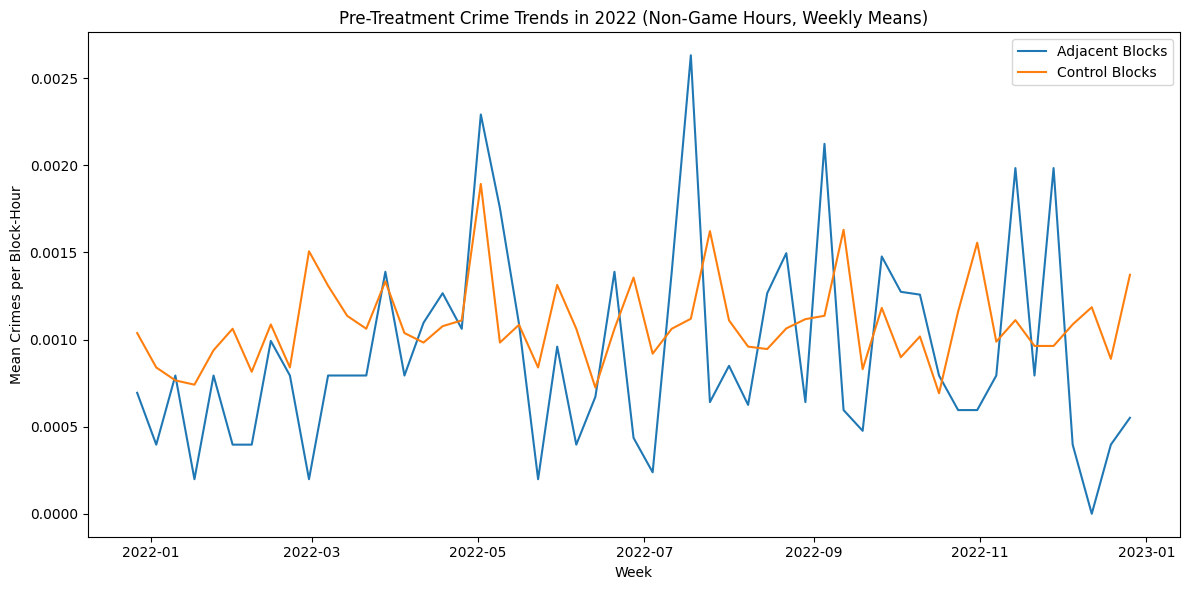

In [39]:
# More viz
nongame_df = pre_change_df[pre_change_df['is_game_hour'] == 0]

weekly_nongame = (
    nongame_df.groupby(['week', 'adjacent'])['crime_count']
              .mean()
              .reset_index()
)

plt.figure(figsize=(12, 6))

for adj_val, label in [(1, "Adjacent Blocks"), (0, "Control Blocks")]:
    temp = weekly_nongame[weekly_nongame['adjacent'] == adj_val]
    plt.plot(temp['week'], temp['crime_count'], label=label)

plt.title("Pre-Treatment Crime Trends in 2022 (Non-Game Hours, Weekly Means)")
plt.xlabel("Week")
plt.ylabel("Mean Crimes per Block-Hour")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# Summary statistics
adjacent_summary_df = summary_df[summary_df["adjacent"] == 1]
control_summary_df = summary_df[summary_df["adjacent"] == 0]

print(summary_df.describe())
print(adjacent_summary_df.describe())
print(control_summary_df.describe())

       crime_count      adjacent  is_game_hour                           date    attendance          Wind  \
count    4747920.0  4.747920e+06  4.747920e+06                        4747920  4.747920e+06  4.747920e+06   
mean      0.001063  1.107011e-01  3.350457e-02  2022-12-31 11:59:59.999997440  1.596307e+03  6.551313e+00   
min            0.0  0.000000e+00  0.000000e+00            2022-01-01 00:00:00  0.000000e+00  0.000000e+00   
25%            0.0  0.000000e+00  0.000000e+00            2022-07-02 00:00:00  0.000000e+00  0.000000e+00   
50%            0.0  0.000000e+00  0.000000e+00            2022-12-31 12:00:00  0.000000e+00  0.000000e+00   
75%            0.0  0.000000e+00  0.000000e+00            2023-07-02 00:00:00  0.000000e+00  1.500000e+01   
max           13.0  1.000000e+00  1.000000e+00            2023-12-31 00:00:00  5.343200e+04  7.700000e+01   
std       0.035743  3.137617e-01  1.799500e-01                            NaN  8.614517e+03  1.030060e+01   

         Visibilit